# 2.7 Training Linear Regression: Normal Equation

We derive the normal equation as a closed-form formula for the weights, and then implement it as a train_linear_regression function.

In [1]:
import numpy as np

### Solving for the Weights

We have the matrix $X$, and we want the predction $g(X) \approx X_{w}$ to be as close to the actual values for $y$.

$X_{w} \approx y$

Ideally, $X_{w}$ equals $y$ exactly, and we can try to solve this system for $w$.

Supposing that $X$ is invertible, there exists a matrix $X^{-1}$ such that $X^{-1}X$ is the identity matrix $I$. Then we can multiply both sideds of the equation by $X^{-1}$:

$X^{-1}X_{w} = X^{-1}y$

$I_{w} = X^{-1}y$

$w = X^{-1}y$

However, there is a problem because $X$ is a rectangular matrix, and is not square. $X$ has $m$ rows (one per car) and $n + 1$ columns (one per feature, plus the bias term). In our dataset $m$ is much larger than $n + 1$, and the matrix is not square. As only square matrices can have an inverse, the solution to this system does not exist.

### Gram Matrix and the Normal Equation

Even though the excact solution does not exist, we can find the closest possible approximate solution, by multiplying both sides of $X_{w} \approx y$ by the transpose of $X$:

$X^{T}X_{w} = X^{T}y$

The matrix $X^{T}X$ is called the Gram matrix.

$w = (X^{T}X)^{-1}X^{T}y$

GRAM MATRIX
$(n + 1) * (n + 1)$

Unlike $X$, the Gram matrix is square: It has $n + 1$ rows and $n + 1$ columns. Square matrices usually have an inverse, so we can multiply both sides by $(X^{T}X)^{-1}$:

$(X^{T}X)^{-1}X^{T}X_{w} = (X^{T}X)^{-1}X^{T}y$

On the left, $(X^{T}X)^{-1}X^{T}X$ is the identity matrix, and $I_{w} = w$. This leaves us with:

$w = (X^{T}X)^{-1}X^{T}y$

$I_{w} = w$

This $w$ is not the solution to the original system, but it is the closest possible solution.

### Implementing the Normal Equation

We will implement this formula step-by-step in NumPy, using a small toy matrix to keep things simple.

In [3]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

The first step of the normal equation is the Gram matrix:

In [4]:
XTX = X.T.dot(X)

Then its inverse:

In [5]:
XTX_inv = np.linalg.inv(XTX)

Sanity-check that the inverse is correct: Multiplying the Gram matrix by its inverse should give the identy matrix

In [6]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [7]:
XTX

array([[ 696471,   44115,  718540],
       [  44115,    7146,  118803],
       [ 718540,  118803, 6359986]])

To serve as a target vector $y$, we will imagine nine prices for this purpose:

In [8]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

Thus we can obtain the weights using the normal equation:

In [9]:
w_full = XTX_inv.dot(X.T).dot(y)

In [10]:
w_full

array([0.26190562, 3.06101252, 0.03696909])

The bias is the baseline prediction, in this case the baseline prediction of the price of a car in the case where we know nothing else about the car. For this reason, the baseline is important, but is not included in what we see above.

To include the bias, we add a column of ones (1) to $X$ and repeat these same steps:

In [11]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

The function `np.column_stack()` serves to stack the vector of ones and the feature matrix together as columns, so that the ones become the first column of $X$.

The resulting `w_full` contains all of the weights. The first element is the bias term The rest are feature weights. We can split these two appart:

In [12]:
w0 = w_full[0]
w  = w_full[1]

In [13]:
w

np.float64(-0.22774252871926765)

In this case, the weights are negative. In this case, as the feature value grows, the predicted price goes down. This would make sense in the case where the feature is the age of the car. In the case where the weights are positive, as a feature increases (such has horsepower), the price will increase.

    Finally here we will wrap everything into a function, that takes `X` and `y`, adds the column of ones internally, applies the normal equation, and then returns the bias term and the weights separately.

In [2]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

Because adding the ones happes inside the function, users do not need to be concerned about the bias term. The user simply passes the feature matrix, and the function itself handles the rest.

### Summary

In order to obtain predictions as close as possle to $y$ target values, it is required that we calculate the weights from the general LR (linear regression) equation.

The feature matrix does not have an inverse because it is not square. It is therefore required to obtain an approximate solution. This is done by using the **Gram matrix**. The Gram matrix is the multiplicdation of the feature matrix $X$ with its transpose $X^T$.

The vector of weights $w$ (a.k.a. coefficients) that is obtained with the preceeding formula is the closest possible solution to the LR system


#### Normal Equation

$w = (X^{T}X)^{-1}X^{T}y$

Where:

$X^{T}X$ is the Gram Matrix.

## 2.8 Baseline Model for Car Price Prediction Project

The `train_linear_regression()` function from the previous unit finds the weights of a linear regression model. Now we will use it on the car price data to build our first mode as a baseline. This is a simplified model that uses only the numerical features. We will use its quality as a reference point upon which to improve.

In [3]:
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
df = pd.read_csv('data.csv')

### Data Preparation

In [5]:
# Headers

df.columns = df.columns.str.lower().str.replace(' ', '_')

strings = list(df.dtypes[df.dtypes == "str"].index)

# Content Data

for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [6]:
# Size of the data frame

n = len(df)

# Divide into three descrete groups, with no records left out

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Create a randomised index

idx = np.arange(n)
np.random.seed(2) # set the random seed for reproducibility and consistency across sessions
np.random.shuffle(idx)

# Split dataframe according to the randomised index

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [7]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
9334,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
5284,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [8]:
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

In [21]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


For training and validation, we use NumPy values rather than Pandas values

In [9]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

### Selecting the Base Features

In [23]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [10]:
# Reference for numerical columns only
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

In [11]:
# Get a subset of coluns from the dataframe. 
# Take the values as a NumPy array
X_train = df_train[base].values

### Dealing with Missing Values

This is what happenens when we try to train the model right away.

In [12]:
w0, w = train_linear_regression(X_train, y_train)

In [13]:
w0

np.float64(nan)

In [14]:
w

array([nan, nan, nan, nan, nan])

So we check for missing values

In [29]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [15]:
# Fill missing values with zeros
X_train = df_train[base].fillna(0).values

When a feature is zero, its term disappears, so the model ignores that feature. It can also work to replace a value with the mean of all of that feature, but in this case we are keeping things simple with zeros.

### Training the Model

In [16]:
w0, w = train_linear_regression(X_train, y_train)

In [32]:
w0 # bias term

np.float64(7.927257388070037)

In [33]:
w

array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
       -9.06908672e-06])

In [17]:
# Bias term price, as the inverse of the logarithm
np.expm1(w0)

np.float64(2770.814359167856)

### Comparing Predictions with Actual Prices

Now we apply the trained model to the training data. We use matrix multiplication, adding the bias term separately.

In [18]:
y_pred = w0 + X_train.dot(w)

We plot a histogram and compare the histogram to the actual target values, using the same `histplot()` function from Seaborn.

The `alpha` parameter controls how transparent the bars are.

<Axes: ylabel='Count'>

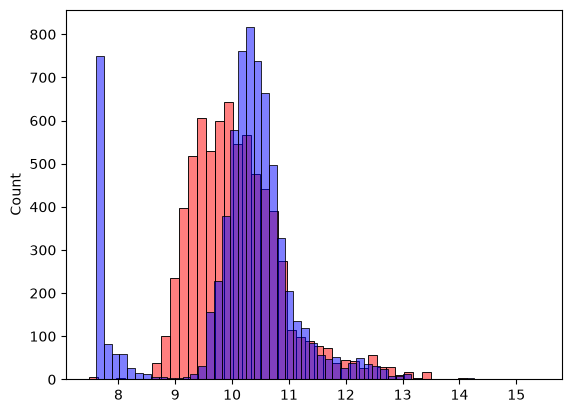

In [19]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

The red values to the left of the blue values means that in many cases the model will predict a smaller value than the actual price.

This is taken to mean that the model is not ideal.

As we work to improve the model, we need an objective way to indicate that the model has improved, which is RMSE.

## 2.9 Root Mean Squared Error (RMSE)

As a chart is not an objective error, in this unit we will **quantify the quality** of a regression model using RMSE.

$i$ each observation
$g(x_{i})$ the prediction we make
$y_i$ the actual value
$m$ number of observations

1. Start with the difference between the prediction and the actual value
2. For each observation $i$, $g(x_{i})$ is the prediciton we make and $y_{i}$ is the actual value
3. Take the difference between $g(x_{i})$ and $y_{i}$
3. Square that difference
4. Average the quared differences over all $m$ observations
5. Finally, take the quare root of that average

### A Small Working Example

We will illustrate using four observations, indicating predictions above actual vbalues

| Set | Zero | One | Two | Three |
| --- | --- | --- | --- | --- |
| y_pred: | 10 | 9 | 11 | 10 |
| y: | 9 | 9 | 10.5 | 11.5 |

In [37]:
y_pred = [10, 9, 11, 10]
y = [9, 9, 10.5, 11.5]
error = y - y_pred

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [20]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [ ]:
rmse (y_train, y_pred)

## 2.10 Computing RMSE on Validation Data

- The validation framework
- Preparing the feature matrix with prepare_X

In [21]:
X_train = df_train[base].fillna(0).values

In [22]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

### Computing the RMSE on Validation Data

In [23]:
X_train = prepare_X(df_train)

w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)

y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7616530991301627)

Meaning that the model behaves on unseen data about as well as on the data that it learned from.

The training part works with the training data set only to prepare the matrix and learn the weights.

The validation part prepares the validation dataset in the same way as the training dataset, then applies the learned model to compute the RMSE for that model.

## 2.11 Feature Engineering

The process of creating new features from the ones that we already have. Here we will create the feature that is the age of the car to see how it improves RMSE.

Subtract df_train.year from the year 2017 to get the age.

Then add the age feature to prepare_X.

The function should not modify the data. So the first line of the function is to take a copy of the dataframe.

In [24]:
def prepare_X(df):
    df = df.copy() # Do not modify the external dataframe directly
    
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

### Checking the Improvement

Validate the model with tyhe same code as before, by preparing the matrices, training the model, applying it to the validation set, then computing the RMSE.

In [25]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5172055461058327)

The RMSE went down from 0.76 to 0.51.

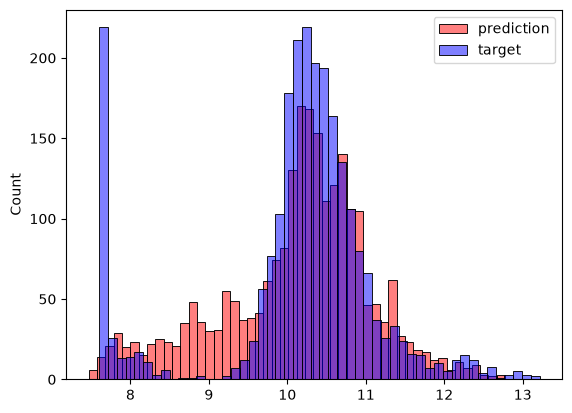

In [26]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue', alpha=0.5, bins=50)
plt.legend()

Adding the feature age of the car to the dataset improved model performance, "but there is still room for improvement".

## 2.12 Categorical Variables

Variables that contain categories instead of numbers. Here we add them to the car price model, but one of them breaks the model. This will be solved in the next unit.

Categorical variables are typically strings (`object` for Alexey or `str` here).

The variable `number_of_doors` looks numerical, but it is actually categorical.

### Encoding Categories as Binary Columns

ML Models can only work with numbes, so we need to encode categorial variables. The typical way of doing this is that for each value of the column, we create a separate binary column. 

| number_of_doors | num_doors_2 | num_doors_3 | num_doors_4 |
| --- | --- | --- | --- |
| 2 | 1 | 0 | 0 |
| 3 | 0 | 1 | 0 |
| 4 | 0 | 0 | 1 |
| 2 | 1 | 0 | 0 |

One categorical column becomes multiple binary columns, and each row gets exactly one `1`. In Pandas, teh comparison operator does most of the work. When we say `df.number_of_doors == 2`, we get `True` for every car that has two doors:

In [38]:
df_train.number_of_doors == 2

0        True
1       False
2       False
3       False
4       False
        ...  
7145     True
7146     True
7147    False
7148    False
7149    False
Name: number_of_doors, Length: 7150, dtype: bool

We turn these zeros into ones and zeros with `astype(int)`. To create the columns, we loop over the valuses `[2, 3, 4]` and use a string template for the name, so that each value gets its own column:


In [41]:
for v in [2, 3, 4]:
    df_train['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')

### Adding Doors to prepare_X

In [42]:
def prepare_X(df):
    df = df.copy()            # Make a copy so as not to write columns to our data
    features = base.copy()    # copy the base list so that age is not appended each time the function runs

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:       # Here each value gets its own column
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [46]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5157995641501902)

Here RMSE is down to 0.5158 from 0.5172. Tt=he improvement is almost negligible, so the number of doors feature is not that useful.

### Adding the Make

The make of the car promises to be more useful.

In [47]:
df.make.value_counts().head()

make
chevrolet     1123
ford           881
volkswagen     809
toyota         746
dodge          626
Name: count, dtype: int64

In [29]:
makes = list(df.make.value_counts().head().index)

In [50]:
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

These are the five most popular makes of cars. So we will include them as one binary column per make.

In [30]:
for v in makes:
    df['make_%s' % v] = (df.make == v).astype('int')
    features.append('make_%s' % v)

NameError: name 'features' is not defined

In [31]:
def prepare_X(df):
    df = df.copy()            # Make a copy so as not to write columns to our data
    features = base.copy()    # copy the base list so that age is not appended each time the function runs

    df['age'] = 2017 - df.year
    features.append('age')

    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [32]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5090963310191564)

### Doing the Same for All Categorical Variables

In [33]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [34]:
def prepare_X(df):
    df = df.copy()            # Make a copy so as not to write columns to our data
    features = base.copy()    # copy the base list so that age is not appended each time the function runs

    df['age'] = 2017 - df.year
    features.append('age')

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [35]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(285.6087359687703)

Categorical variables are typically represented as strings, and pandas identifies them as object types. However, some variables that appear to be numerical may actually be categorical.

All these categorical variables need to be converted to a numerical form because ML models can interpret only numerical features.

This way of encoding categorical features is called "one-hot encoding". We'll learn more about it in Session 3.

## 2.13 Regularization

The formula we used to train our model:

$$
w = (X^{T}X)^{-1} * X^{T}y
$$

In the blow matrix, the second and third columns are the same. In this case, an inverse will not exist. ("One column is a linear combination of the other columns")

Adding a tiny bit of noise to the matrix makes it no longer singular and numerically invertable, so NumPy can find an inverse.

In [40]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5],
]
np.linalg.inv(X)

LinAlgError: Last 2 dimensions of the array must be square

In [41]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001],
]
np.linalg.inv(X)

LinAlgError: Last 2 dimensions of the array must be square

When we use this inverse to compute the weights, the weights for the duplicated features turn out to be very large numbers too. The weight for the unique first feature is fine - 0.62 - but for the second and third features we get something like 3.4 million and -3.4 million.

So whenever we have duplicates or near-duplicates in our feature matrix, we get this problem.

This can be illustrated with a smaller matrix.

In [37]:
XTX = [
    [1, 2, 2],
    [2, 1, 1],
    [2, 1, 1],
]

In [38]:
np.linalg.inv(XTX)

LinAlgError: Singular matrix

In [42]:
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1],
]
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

### Controlling the weights with regularization

To solve this problem, we can add a small number to the diagonal of the matrix. If we add a small number to the diagonal - say 0.01 - the inverse can still be found, and the numbers in it are much more under control. The larger the number we add to the diagonal, the more control we get over the weights.

Using `np.eye(3)`, the diagonal increases by one.

`XTX + np.eye(3)`

To add only a small number, we multiply the identity matrix by that number first.

`XTX = XTX + 0.01 * np.eye(3)`

The intention in regularization is to control / regulate the weights so that they do not grow too much.

The number we add is actually a parameter. The larger the number on the diagonal, the smaller the values in the inverse of $X^{T}X$. How much regularization to add becomes a parameter of our model.

### The Regularized Training Function

The additional parameter `r` is short for regularization.

In [43]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0]) # The core calulation

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [44]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4581127318377536)

Adding a factor to the diagonals of a Gram Matrix for the purpose of regularization is referred to as **Ridge Regression**.

## 2.14 Tuning the Model

Tuning the model means finding the best value for regularization parameter `r`. The validation set is used for this.

In the below example we try different values of `r` from zero to ten.

In [54]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(f"{r:>10}, {w0:>25}, {score:>20}")

       0.0,    -6.564470323326965e+16,    285.6087359687703
     1e-05,         5.233485484916178,   0.4581093363995708
    0.0001,         5.911352044504025,   0.4581093670086991
     0.001,         5.908053916065584,   0.4581096695398425
       0.1,         5.890076828683002,  0.45814669187304213
         1,           5.7364107236679,  0.45877526896062926
        10,         4.784055066459362,   0.4744097895239015


regularisation parameter, bias term, RMSE score

An `r` value of `0.001` looks like a value with good performance.

In [55]:
### Training the final model

In [56]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4581096695398425)

Tuning the model consisted of finding the best regularization hyperparameter value, using the validation partition of the dataset. The model was then trained with this regularization value.

## 2.15 Using the Model

For the final model we combine the training and validation datasets into one, train the model on all of it, and then make the final evaluation on the test dataset.

The idea is simple: now that we have tuned all the parameters, we want to give the model as much data as possible for training, and keep the test set untouched for the final check. The RMSE on test shouldn't be too different from what we saw on validation.

In [57]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

Now everything is sequential, and we can use the `prepare_X` function to get the feature matrix.

We also need the target values `y`, and obtain them using `np.concatenate()`.

In [60]:
X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [61]:
w0 # weights

np.float64(5.935551556988477)

In [62]:
w # final model

array([ 1.62971752e-03,  1.15167667e-01, -6.00307412e-03, -6.39567452e-03,
       -5.16661885e-05, -9.85539629e-02, -4.41122865e-02,  1.74605430e-01,
       -1.67235529e-02, -9.20401548e-02, -9.41338692e-02, -4.48072683e-01,
        8.42159479e-02, -3.18441133e-01, -5.63968929e-01, -4.80053917e-02,
        1.00773911e+00,  8.17190850e-01,  1.04276573e+00,  2.68826862e+00,
        3.81895876e-01,  1.54271361e+00,  1.41891992e+00,  1.52006828e+00,
        1.45423448e+00, -9.63065198e-02,  4.58969687e-02, -3.74569344e-02,
       -7.24854825e-02, -1.68124583e-02,  2.06329174e+00,  1.94052994e+00,
        1.93211461e+00,  1.16134759e-02,  1.12089666e-01,  1.02632625e-01,
        2.49276628e-01, -6.80973641e-02])

### Check the Model on Test Data

To check the final model, replace validation with test. Otherwise this is the same test dataset as we had with the validation dataset. 

In [64]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.45421903387322793)

### Predicting the Price of a Car

In [65]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031,
 'msrp': 35000}

Our `prepare_X()` expects a dataframe. We create a small dataframe with a single row. Pandas can create a dataframe from a list of dictionaries. Our list contains just the one car from the request.

Then we apply the model to this feature matrix with one row.

In [66]:
# Create a dataframe from a list of dictionaries containing just the one car

df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

# Apply the model to this feature matrix with one row

y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.435275954938827)

In [67]:
np.expm1(y_pred)

np.float64(34038.46803559835)

This is the prediction. (In the book, Alexey's prediction was 41459.3367...) How much did the car actually cost?

In [68]:
np.expm1(y_test[20])

np.float64(35000.00000000001)

## 2.16 Car Price Prediction Project Summary

1. Dataset of cars with prices and different characteristics
2. Data preparation
3. EDA (exploratory data analysis)
4. The validation framework
5. Linear regression and normal equation
6. Feature engineering and categorical variables
7. Tuning and the final model